In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_palette("Set2")

%matplotlib inline

df = pd.read_csv("retail_sales_dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [28]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset: (1000, 9)

Column Names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

Data Types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [ ]:
## Observation
# - The dataset contains customer demographic information along with transaction details.
# - The structure of the dataset is suitable for analysis.
# - The next step is to convert the Date column into datetime format and perform descriptive 
# statistical analysis.

In [29]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract Month, Quarter and Year
df['Month'] = df['Date'].dt.month_name()
df['Quarter'] = df['Date'].dt.quarter
df['Year'] = df['Date'].dt.year

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Quarter,Year
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,November,4,2023
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,February,1,2023
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,January,1,2023
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,May,2,2023
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,May,2,2023


In [ ]:
## Observation - The Date column has been successfully converted into datetime format. 
# Additional columns (Month, Quarter, and Year) have been created to facilitate time-series analysis.

In [30]:
# Summary statistics
df.describe(include='all')

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Quarter,Year
count,1000.000000,1000,1000,1000,1000.00000,1000,1000.000000,1000.000000,1000.000000,1000,1000.000000,1000.000000
unique,NaN,NaN,1000,2,NaN,3,NaN,NaN,NaN,12,NaN,NaN
top,NaN,NaN,CUST001,Female,NaN,Clothing,NaN,NaN,NaN,May,NaN,NaN
freq,NaN,NaN,1,510,NaN,351,NaN,NaN,NaN,105,NaN,NaN
mean,500.500000,2023-07-03 00:25:55.200000256,NaN,NaN,41.39200,NaN,2.514000,179.890000,456.000000,NaN,2.525000,2023.002000
min,1.000000,2023-01-01 00:00:00,NaN,NaN,18.00000,NaN,1.000000,25.000000,25.000000,NaN,1.000000,2023.000000
25%,250.750000,2023-04-08 00:00:00,NaN,NaN,29.00000,NaN,1.000000,30.000000,60.000000,NaN,2.000000,2023.000000
50%,500.500000,2023-06-29 12:00:00,NaN,NaN,42.00000,NaN,3.000000,50.000000,135.000000,NaN,2.000000,2023.000000
75%,750.250000,2023-10-04 00:00:00,NaN,NaN,53.00000,NaN,4.000000,300.000000,900.000000,NaN,4.000000,2023.000000
max,1000.000000,2024-01-01 00:00:00,NaN,NaN,64.00000,NaN,4.000000,500.000000,2000.000000,NaN,4.000000,2024.000000


In [31]:
# Mean, Median, Mode and Standard Deviation

numerical_cols = df.select_dtypes(include=np.number)

statistics = pd.DataFrame({
    'Mean': numerical_cols.mean(),
    'Median': numerical_cols.median(),
    'Mode': numerical_cols.mode().iloc[0],
    'Standard Deviation': numerical_cols.std()
})

statistics

,Mean,Median,Mode,Standard Deviation
Transaction ID,500.500,500.5,1.0,288.819436
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632
Quarter,2.525,2.0,2.0,1.119208
Year,2023.002,2023.0,2023.0,0.044699


In [ ]:
## Observation - The descriptive statistics provide an overview of the dataset. 
# Measures such as mean, median, mode, and standard deviation help understand the distribution 
# and variability of numerical features like Age, Quantity, Price per Unit, and Total Amount.

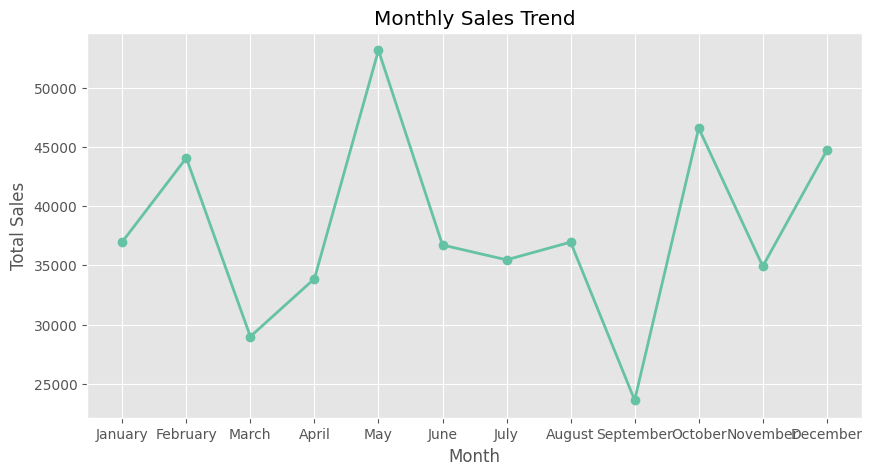

In [33]:
# Monthly Sales Trend Analysis
monthly_sales = df.groupby("Month")["Total Amount"].sum()

# Arrange months in calendar order
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linewidth=2)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(True)
plt.show()

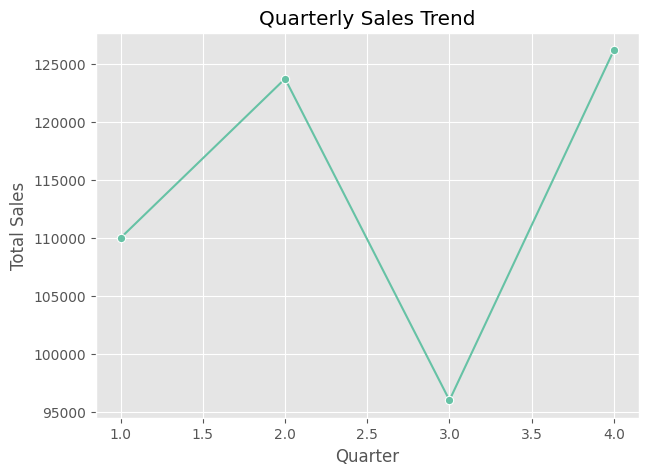

In [17]:
# Quarterly Sales Analysis
quarterly_sales = df.groupby("Quarter")["Total Amount"].sum()

plt.figure(figsize=(7,5))
sns.lineplot(x=quarterly_sales.index, y=quarterly_sales.values, marker="o")

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.show()

In [ ]:
## Observation 
# Quarterly analysis provides a broader view of business performance. 
# Comparing quarterly sales helps identify long-term trends and seasonal business cycles.

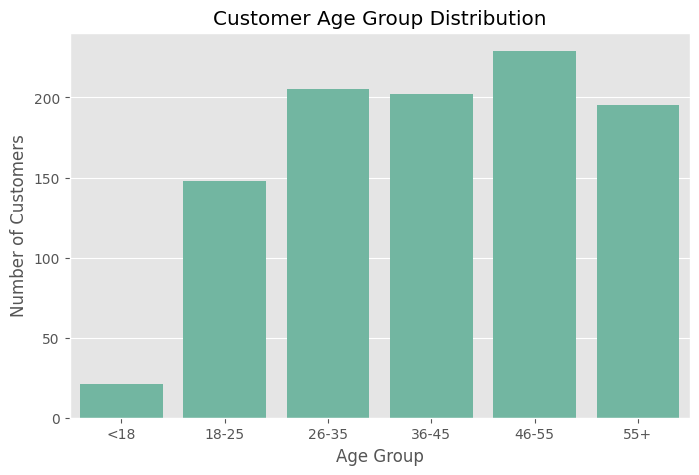

In [21]:
# Customer Demographics Analysis

labels = ["<18","18-25","26-35","36-45","46-55","55+"]

df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Age Group")

plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.show()

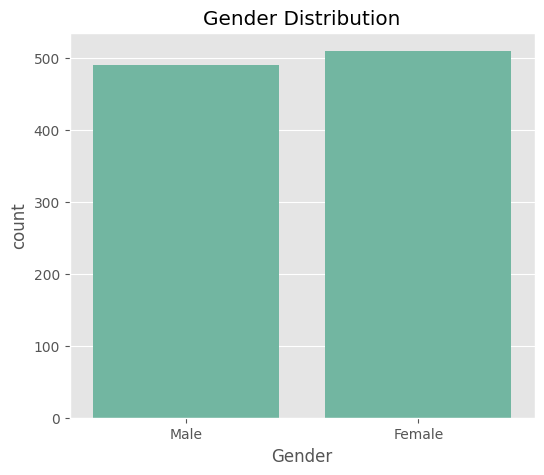

In [22]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="Gender")

plt.title("Gender Distribution")

plt.show()

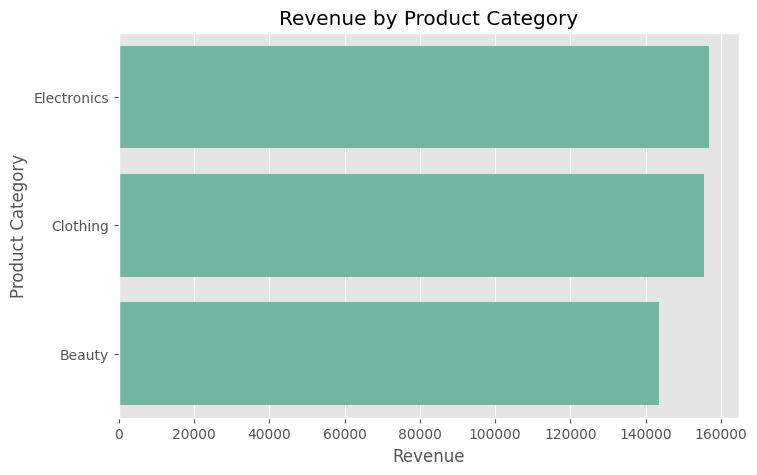

In [23]:
top_categories = (
    df.groupby("Product Category")["Total Amount"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
sns.barplot(x=top_categories.values, y=top_categories.index)

plt.title("Revenue by Product Category")
plt.xlabel("Revenue")
plt.ylabel("Product Category")

plt.show()

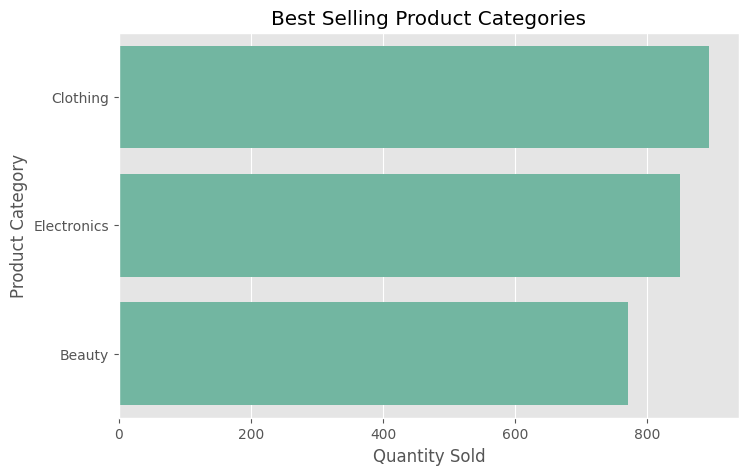

In [24]:
top_products = (
    df.groupby("Product Category")["Quantity"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
sns.barplot(x=top_products.values, y=top_products.index)

plt.title("Best Selling Product Categories")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Category")

plt.show()

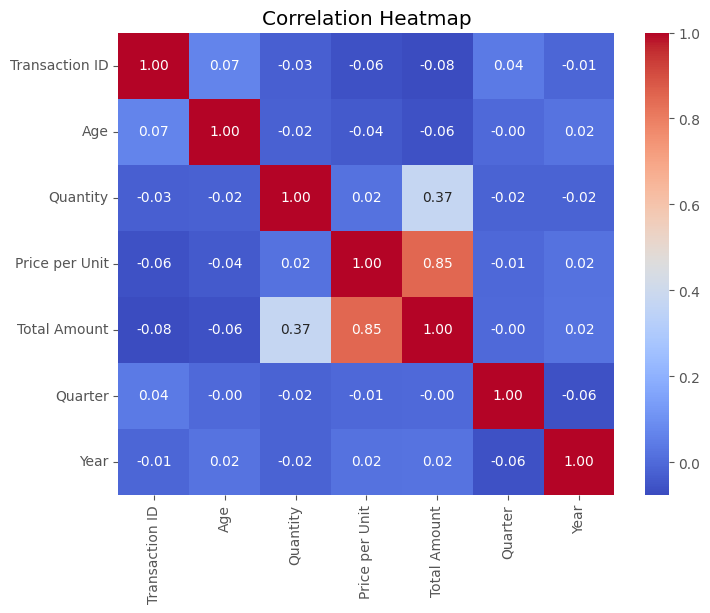

In [25]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

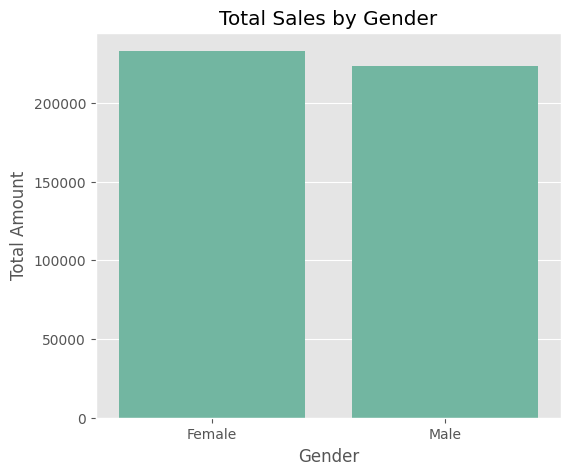

In [26]:
sales_gender = (
    df.groupby("Gender")["Total Amount"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(6,5))

sns.barplot(data=sales_gender,
            x="Gender",
            y="Total Amount")

plt.title("Total Sales by Gender")

plt.show()

In [ ]:
# Conclusion
# This exploratory data analysis revealed important insights into retail sales performance, 
# customer demographics, and product category trends.

#Key findings include:

#- Customer purchasing behaviour varies across different demographic groups.
#- Certain product categories contribute significantly more revenue than others.
#- Sales trends indicate seasonal patterns that can guide inventory and promotional planning.

#Overall, these insights can help businesses improve decision-making, optimise inventory management, 
# and enhance customer engagement strategies.